Classificazione k-NN

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
data=load_breast_cancer()
X=data.data
y=data.target

In [4]:
display(pd.DataFrame(X,columns=data.feature_names))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
display(pd.DataFrame(y,columns=["target"]))  #divide tra tumore maligno(1) o benigno(0)

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


Standarizzo

In [11]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

Cerco il k ottimale con il motodo del Elbow Method

In [12]:
k_range=range(1,21)
errore_rate=[]

#prendo solo i range di k dispari
k_range_odd = [k for k in k_range if k % 2 != 0]

for k in (k_range_odd):
    knn_clf=KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_scaled,y)
    y_pred=knn_clf.predict(X_scaled)
    errore_rate.append (1-accuracy_score(y,y_pred))


In [13]:
print(len(errore_rate))

10


plot del Elbow method

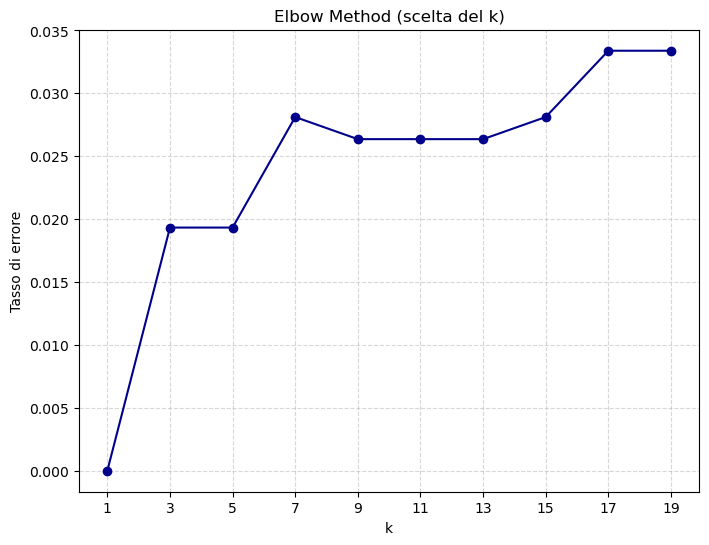

In [16]:
plt.figure(figsize=(8,6))
plt.plot(k_range_odd, errore_rate, marker="o", linestyle="-",color="darkblue")
plt.title("Elbow Method (scelta del k)")
plt.xlabel("k")
plt.ylabel("Tasso di errore")
plt.xticks(k_range_odd)
plt.grid(True,linestyle="--",alpha=0.5)
plt.show()

k=7 il migliore, la curva non fa proprio un gomito ma il punto di flesso è k=7, tutti i valori superiori di 7 non vanno ad aumentare notevolmente il tasso di errore.

In [ ]:
best_k=7

knn_final=KNeighborsClassifier(n_neighbors=best_k)
#prendo solo le prime due feature
feature_0=0
feature_1=1
#faccio un dataframe di 2 dimensioni
X_2d=X_scaled[:,[feature_0,feature_1]]
#print(X_2d)

knn_final.fit(X_2d,y)
y_pred=knn_final.predict(X_2d)


plot dei confini di decisione che ha rilevato il classificatore

In [30]:

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5 #trovo il minimo ed il massimo ed aggiungo uno spazio (0.5)
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5 #trovo il minimo ed il massimo ed aggiungo uno spazio (0.5)
#gridgli rettangolare, in cui i punti saranno equispaziati
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z=knn_final.predict(np.c_[xx.ravel(), yy.ravel()])
Z=Z.reshape(xx.shape)

C:\Users\uberti\AppData\Local\Temp\ipykernel_8724\45705962.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


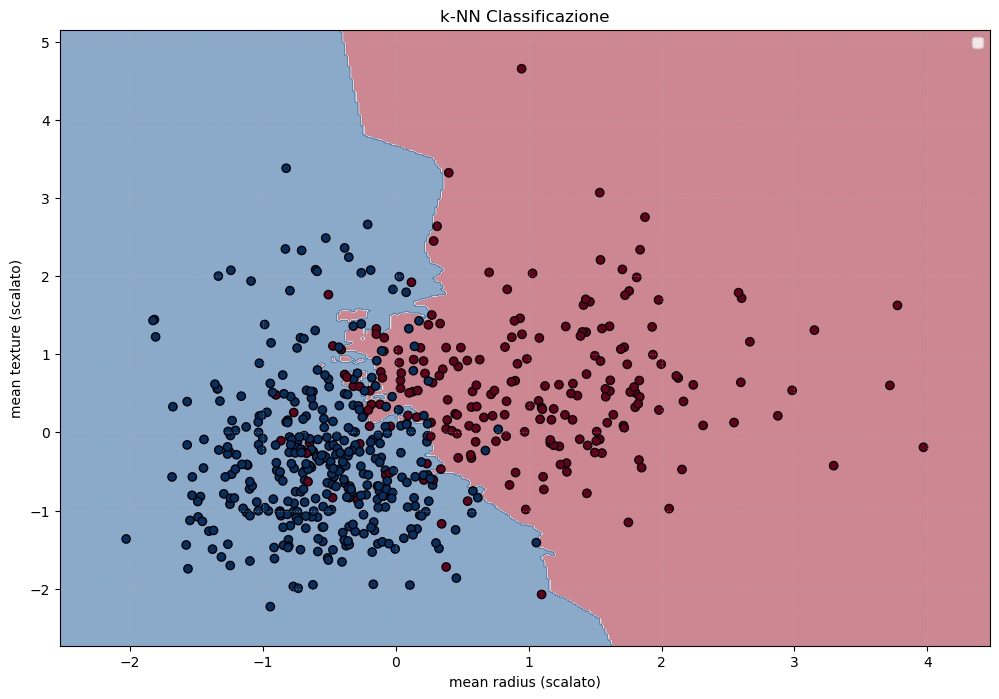

In [34]:
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.RdBu)  #confini decisionali

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdBu)

plt.title(f"k-NN Classificazione")
plt.xlabel(f"{data.feature_names[feature_0]} (scalato)")
plt.ylabel(f"{data.feature_names[feature_1]} (scalato)")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

plt.xticks()
plt.yticks()
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

si vede qual'è il confine decisionale che ha trovato il classificatore
a dx ci sono la maggior parte dei punti rossi che sono stati ben assegnati, ma nel 
confine su sinistra vediamo che ci sono ancora alcuni punti rossi e qui il modello non ha classificato bene
Controlliamo quandi sono questi punti 

In [36]:
tot_samples = len(y)

correct_arr = (y_pred == y)
correct_count = np.sum(correct_arr)
incorrect_count = tot_samples - correct_count
print(f"TOT:\t{tot_samples}")
print(f"Corretti:\t{correct_count}")
print(f"Incorretti:\t{incorrect_count}")

accuracy = correct_count /tot_samples
print(f"ACCURACY:\t{accuracy * 100:.2f}%")


TOT:	569
Corretti:	550
Incorretti:	19
ACCURACY:	96.66%


accuracy ottima il 96.66% fitta bene